In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from vta.utils import CCF

%matplotlib inline
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", font_scale=0.8, rc=custom_params)
%config InlineBackend.figure_format='retina'

%load_ext autoreload
%autoreload 2

In [ ]:
import os

# Create the directory if it doesn't exist
os.makedirs("/results/plots", exist_ok=True)

In [ ]:
# read in csv file containing cell coordinates
df_ccf = pd.read_csv("/results/FINAL_manual_proofread_ccf_37brains.csv")
ccf = CCF()

In [4]:
# Filter out thalamic pressure injection samples given they might be a mixture of TH and CTX projecting neurons
print(df_ccf.shape)
df_ccf = df_ccf[df_ccf["injection_region"] != "TH"]
print(df_ccf.shape)

(15876, 7)
(13665, 7)


In [5]:
# Get the number of unique brains
n_brains = df_ccf["brain"].nunique()

# Combine palettes for enough colors
# Pastel2 without last color (grey)
pastel2 = sns.color_palette("Pastel2", 8)[:-1]
# Set3 without 9th color (index 8)
set3 = [c for i, c in enumerate(sns.color_palette("Set3", 12)) if i != 8]
# Tab20 reversed, without 9th and 10th colors (indices 8 and 9)
tab20_reversed = [c for i, c in enumerate(sns.color_palette("tab20", 20)[::-1]) if i not in [8, 9]]
combined_palette = pastel2 + set3 + tab20_reversed

# Truncate to the number of unique brains
palette = combined_palette[:n_brains]

# function to plot counts data per brain region and sample
def plot_brain_data(df, dataset_name):
    f, ax = plt.subplots(1, 1, figsize=(5, 6))
    (
        so.Plot(df, x="injection_region", color="brain")
        .on(ax)
        .add(so.Bar(), so.Count(), so.Stack())
        .scale(color=palette, title="Brain")
        .label(x="Injection region", y="LC-NE cell count", color="Sample ID")
        .plot()
    )
    ax.set_title(f"Dataset: {dataset_name}")  # Set the title to the dataset name
    plt.tight_layout()
    plt.show()

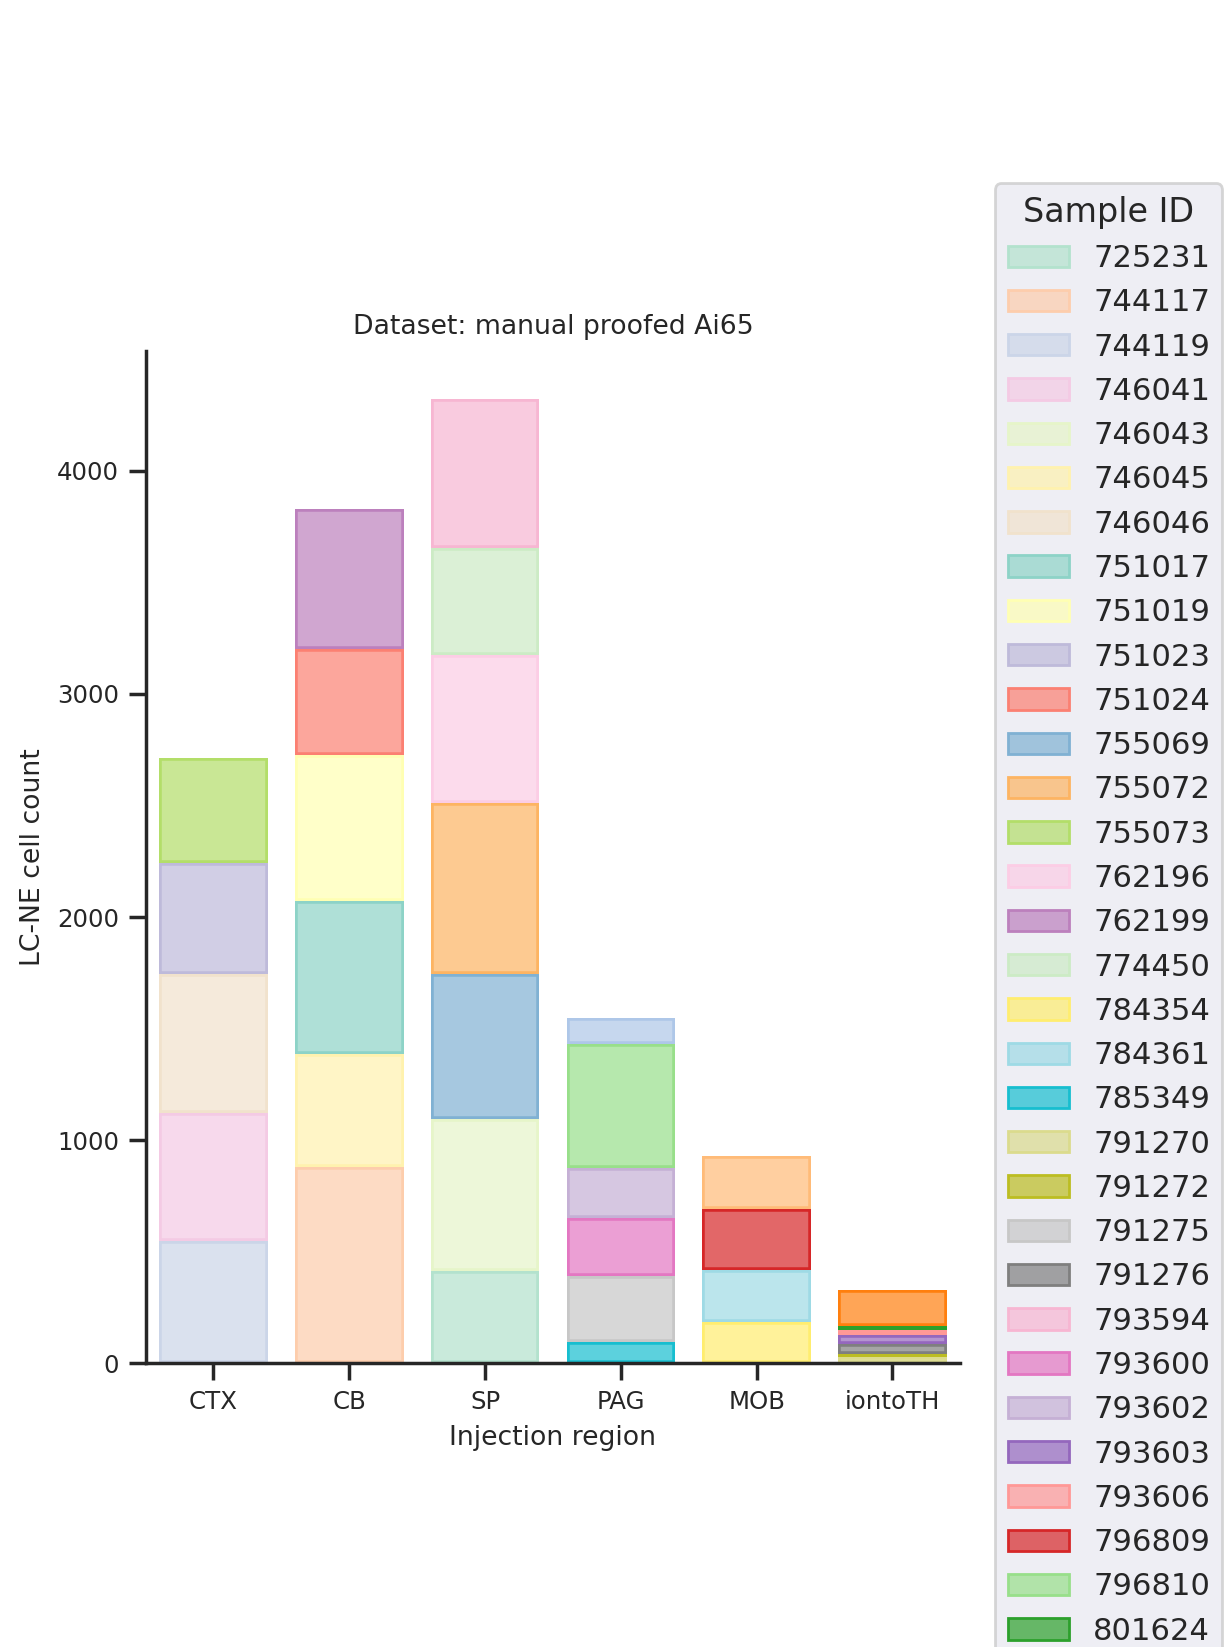

In [6]:
plot_brain_data(df_ccf, "manual proofed Ai65")

In [7]:
# rename x, y, z columns to their corresponding ccf dimentions RC, DV, ML
df_ccf = df_ccf.rename(columns={"x": "ML", "y": "DV", "z": "RC"})

# using an approximate midline value based on the barplot
approx_midline = 230
df_ccf["ipsi"] = df_ccf["ML"] > 230
display(df_ccf.head(5))
print("Unique injection regions", df_ccf["injection_region"].unique())
print("Laterality assignment", df_ccf["ipsi"].unique())

,brain,channel,injection_region,ML,DV,RC,batch,ipsi
0,746046,561,CTX,261.107788,160.238174,426.496399,final,True
1,746046,561,CTX,260.630951,162.411804,426.451996,final,True
2,746046,561,CTX,260.420593,163.047180,426.273346,final,True
3,746046,561,CTX,258.255768,168.814880,424.967255,final,True
4,746046,561,CTX,254.746948,170.891434,423.269836,final,True


Unique injection regions ['CTX' 'CB' 'SP' 'PAG' 'MOB' 'iontoTH']
Laterality assignment [ True False]


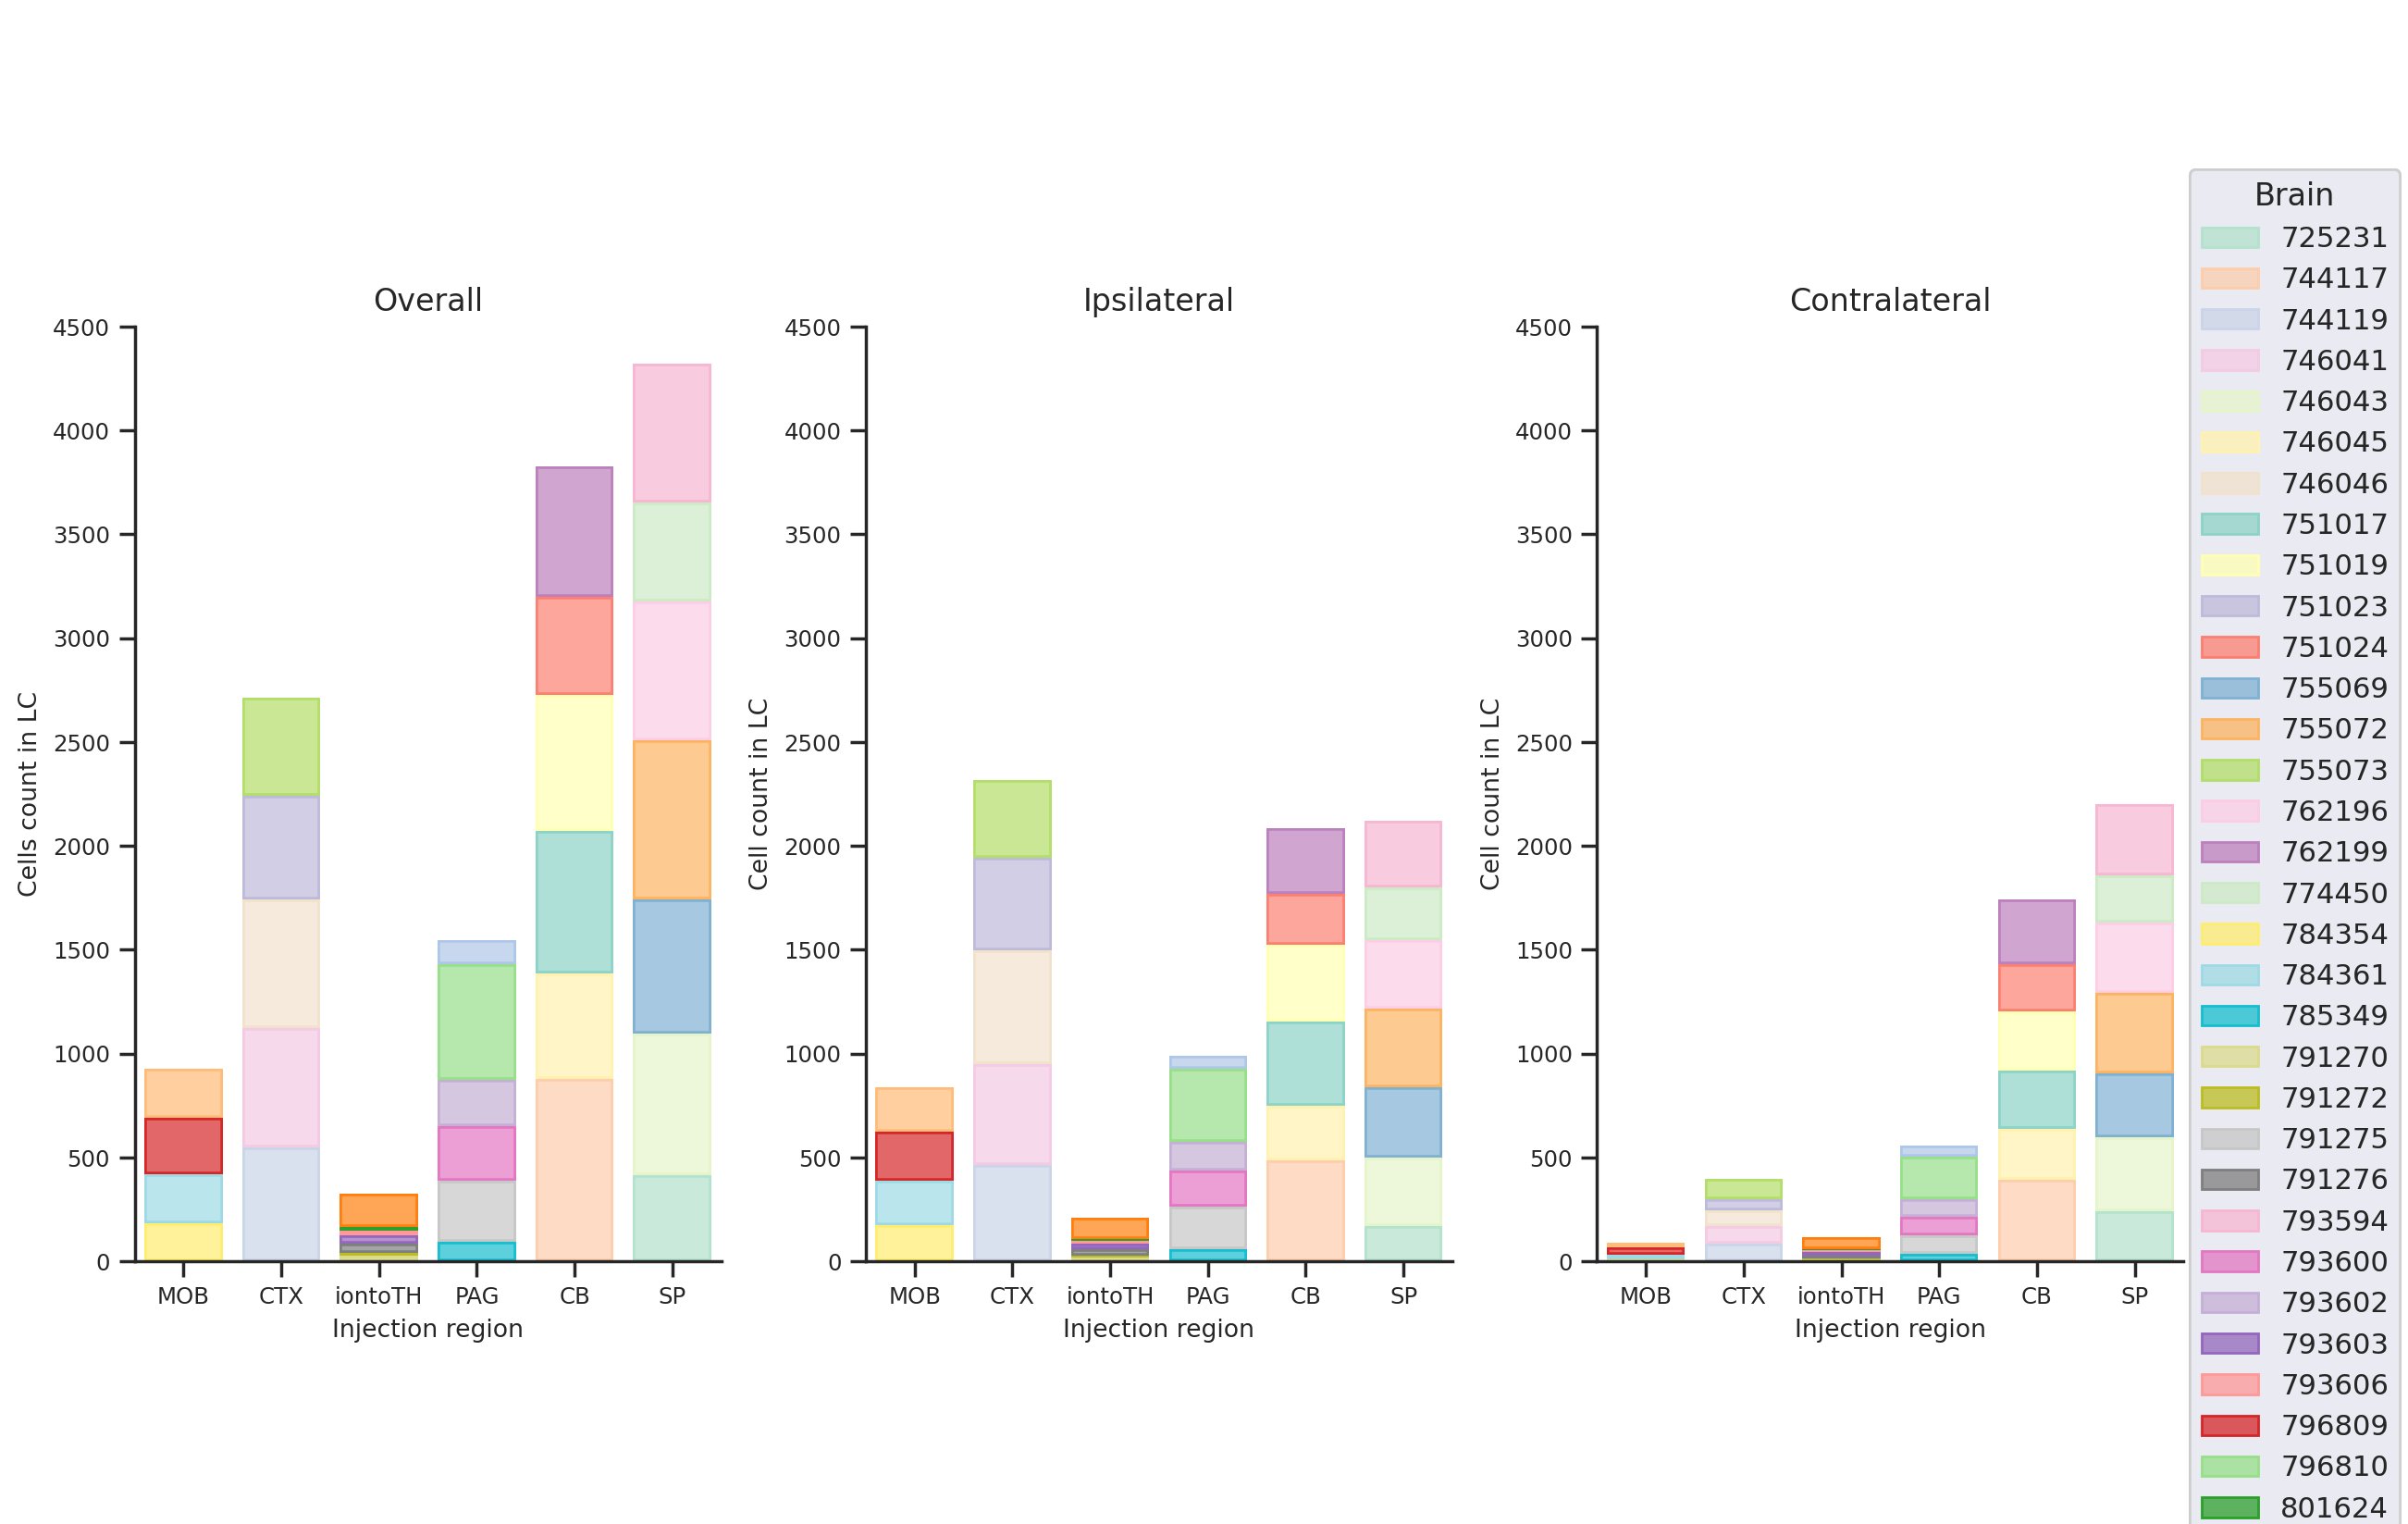

In [ ]:
# Set the order of the injection_region from anterior to posterior
order = ["MOB", "CTX", "iontoTH", "PAG", "CB", "SP"]
df_ccf["injection_region"] = pd.Categorical(df_ccf["injection_region"], categories=order, ordered=True)

# distribution of segmented cells in ipsilateral and contralateral LC w.r.t. injection region
f, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 6))
(
    so.Plot(df_ccf, x="injection_region", color="brain")
    .on(ax0)
    .add(so.Bar(), so.Count(), so.Stack())
    .scale(color=palette, title="Brain")
    .label(x="Injection region", y="Cells count in LC", color="Brain", title="Overall")
    .limit(y=(0, 4500))
    .plot()
)

(
    so.Plot(df_ccf[df_ccf["ipsi"] == True], x="injection_region", color="brain")
    .on(ax1)
    .add(so.Bar(), so.Count(), so.Stack())
    .scale(color=palette, title="Brain")
    .label(x="Injection region", y="Cell count in LC", color="Brain", title="Ipsilateral")
    .limit(y=(0, 4500))
    .plot()
)

(
    so.Plot(df_ccf[df_ccf["ipsi"] == False], x="injection_region", color="brain")
    .on(ax2)
    .add(so.Bar(), so.Count(), so.Stack())
    .scale(color=palette, title="Brain")
    .label(x="Injection region", y="Cell count in LC", color="Brain", title="Contralateral")
    .limit(y=(0, 4500))
    .plot()
)

plt.tight_layout()
# Save as PDF
plt.savefig("/results/plots/ipsi_contra_cell_counts_per_region_barplot.pdf", dpi=300, bbox_inches="tight")
# Save as SVG
plt.savefig("/results/plots/ipsi_contra_cell_counts_per_region_barplot.svg", dpi=300, bbox_inches="tight")
plt.show()

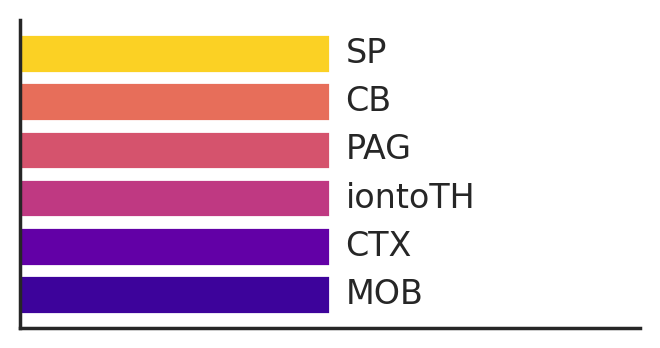

In [9]:
# define color codes for each ROI
cols_hex = ["#3D039B", "#6200A6", "#BF3982", "#D5536D", "#E76E5A", "#FBD124"]
region_col_map = dict(zip(["MOB", "CTX", "iontoTH", "PAG", "CB", "SP"], cols_hex))

fig, ax = plt.subplots(figsize=(4, 2))
for i, (region, color) in enumerate(region_col_map.items()):
    ax.barh(i, 1, color=color)
    ax.text(1.05, i, region, va='center', fontsize=12)
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 2)
plt.show()

In [10]:
ipsi_value = True  # Change to False for contralateral data
df_ipsi = df_ccf[df_ccf["ipsi"] == ipsi_value].copy()

ipsi_value = False  # Change to True for ipsilateral data
df_contra = df_ccf[df_ccf["ipsi"] == ipsi_value].copy()

order = ["MOB", "CTX", "iontoTH", "PAG", "CB", "SP"]

In [ ]:
def plot_ml_dv_density_by_injection_region(
    df: pd.DataFrame,
    desired_order=None,
    region_col_map=None,
    ml_col="ML",
    dv_col="DV",
    region_col="injection_region",
    bins=100,
    levels=15,
    cmap="viridis",
    figsize=None,
    save_path=None,
    show=True,
    group_label=None,          # "ipsi" or "contra" etc.
    region_titles_simple=True, # If True, subplot titles are just region names
    title_prefix="Injection Region"
):
    """
    Plot ML vs DV density (2D histogram + contourf) per injection region.

    Parameters
    ----------
    df : DataFrame with ML, DV, and region columns.
    desired_order : list[str] or None. Order of regions.
    region_col_map : dict region->color for border spines.
    ml_col, dv_col, region_col : str. Column names.
    bins : int. Number of bins each axis (uniform).
    levels : int. Contour levels.
    cmap : str. Matplotlib colormap.
    figsize : tuple or None. Defaults to (4 * n_regions, 6).
    save_path : str or None. If None and group_label set, auto filename.
    show : bool. Call plt.show().
    group_label : str or None. Adds suptitle & filename prefix.
    region_titles_simple : bool. If True, per-panel titles are region only.
    title_prefix : str. Used if region_titles_simple is False.

    Returns
    -------
    fig, axs
    """
    df_local = df.copy()

    if desired_order is None:
        desired_order = list(df_local[region_col].dropna().unique())

    df_local = df_local[df_local[region_col].isin(desired_order)]
    df_local[region_col] = pd.Categorical(df_local[region_col],
                                          categories=desired_order,
                                          ordered=True)
    df_local = df_local.sort_values(region_col)

    injection_regions = df_local[region_col].unique()
    if len(injection_regions) == 0:
        raise ValueError("No regions after filtering desired_order.")

    dv_min, dv_max = df_local[dv_col].min(), df_local[dv_col].max()
    ml_min, ml_max = df_local[ml_col].min(), df_local[ml_col].max()

    n_regions = len(injection_regions)
    if figsize is None:
        figsize = (4 * n_regions, 6)

    fig, axs = plt.subplots(1, n_regions, figsize=figsize, squeeze=False)
    axs = axs.ravel()

    ml_edges = np.linspace(ml_min, ml_max, bins)
    dv_edges = np.linspace(dv_min, dv_max, bins)

    for i, region in enumerate(injection_regions):
        region_data = df_local[df_local[region_col] == region]
        x = region_data[ml_col].values
        y = region_data[dv_col].values

        hist, xedges, yedges = np.histogram2d(
            x, y, bins=[ml_edges, dv_edges], density=True
        )
        xi, yi = np.meshgrid(xedges[:-1], yedges[:-1])
        cs = axs[i].contourf(xi, yi, hist.T, levels=levels, cmap=cmap)

        cbar = fig.colorbar(cs, ax=axs[i])
        cbar.set_label("Density")

        if region_titles_simple:
            axs[i].set_title(str(region))
        else:
            axs[i].set_title(f"{title_prefix}: {region}")

        axs[i].set_xlabel(ml_col)
        axs[i].set_ylabel(dv_col)
        axs[i].set_xlim(ml_min, ml_max)
        axs[i].set_ylim(dv_min, dv_max)
        axs[i].invert_yaxis()

        if region_col_map and region in region_col_map:
            for spine in axs[i].spines.values():
                spine.set_edgecolor(region_col_map[region])
                spine.set_linewidth(3)

    # Add subtitle if group_label provided
    if group_label:
        fig.suptitle(f"{group_label.capitalize()} Density in Coronal Plane by Injection Region", fontsize=16)
        # Adjust layout to make room for suptitle
        fig.tight_layout(rect=[0, 0, 1, 0.93])
    else:
        fig.tight_layout()

    if save_path is not None or group_label is not None:
        if save_path is None and group_label:
            # Auto-generate filename
            base_filename = f"density_ML-DV_{cmap}_{group_label}"
        elif save_path:
            # Use provided save_path, extract just the filename
            base_filename = os.path.basename(save_path.rsplit('.', 1)[0] if '.' in save_path else save_path)
        else:
            base_filename = f"density_ML-DV_{cmap}"

        # Always save to /results/plots/
        pdf_path = f"/results/plots/{base_filename}.pdf"
        svg_path = f"/results/plots/{base_filename}.svg"
        
        fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
        fig.savefig(svg_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    return fig, axs


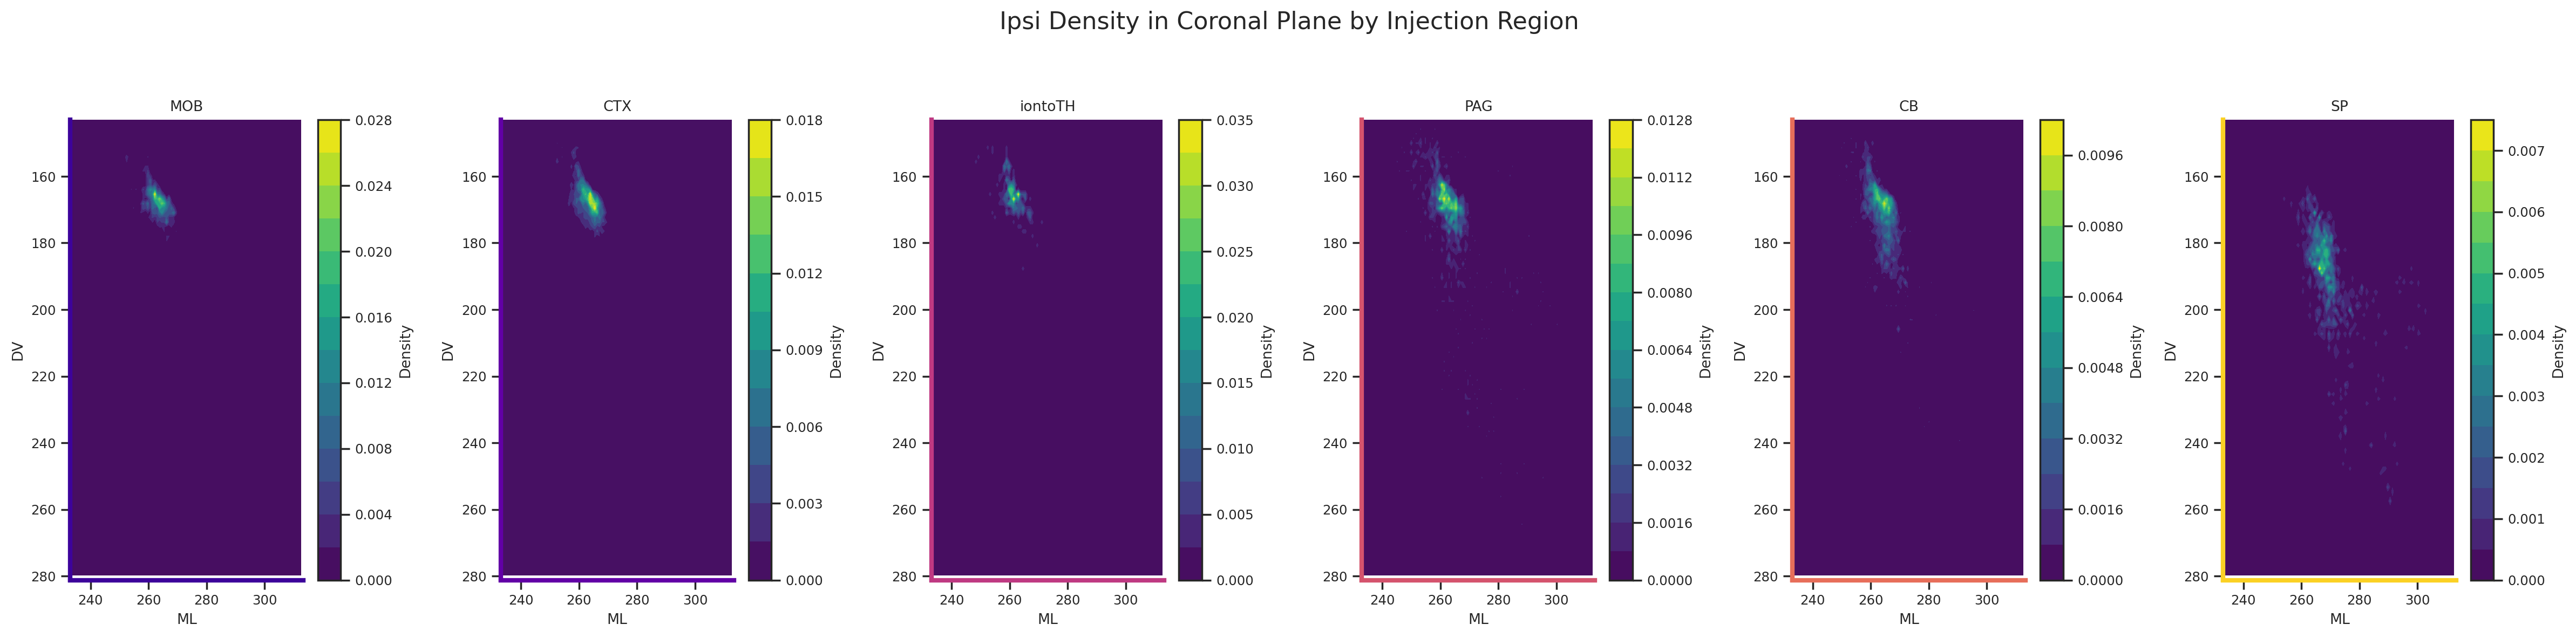

In [12]:
fig_ipsi, axs_ipsi = plot_ml_dv_density_by_injection_region(
    df_ipsi,
    desired_order=["MOB", "CTX", "iontoTH", "PAG", "CB", "SP"],
    region_col_map=region_col_map,
    group_label="ipsi"
)

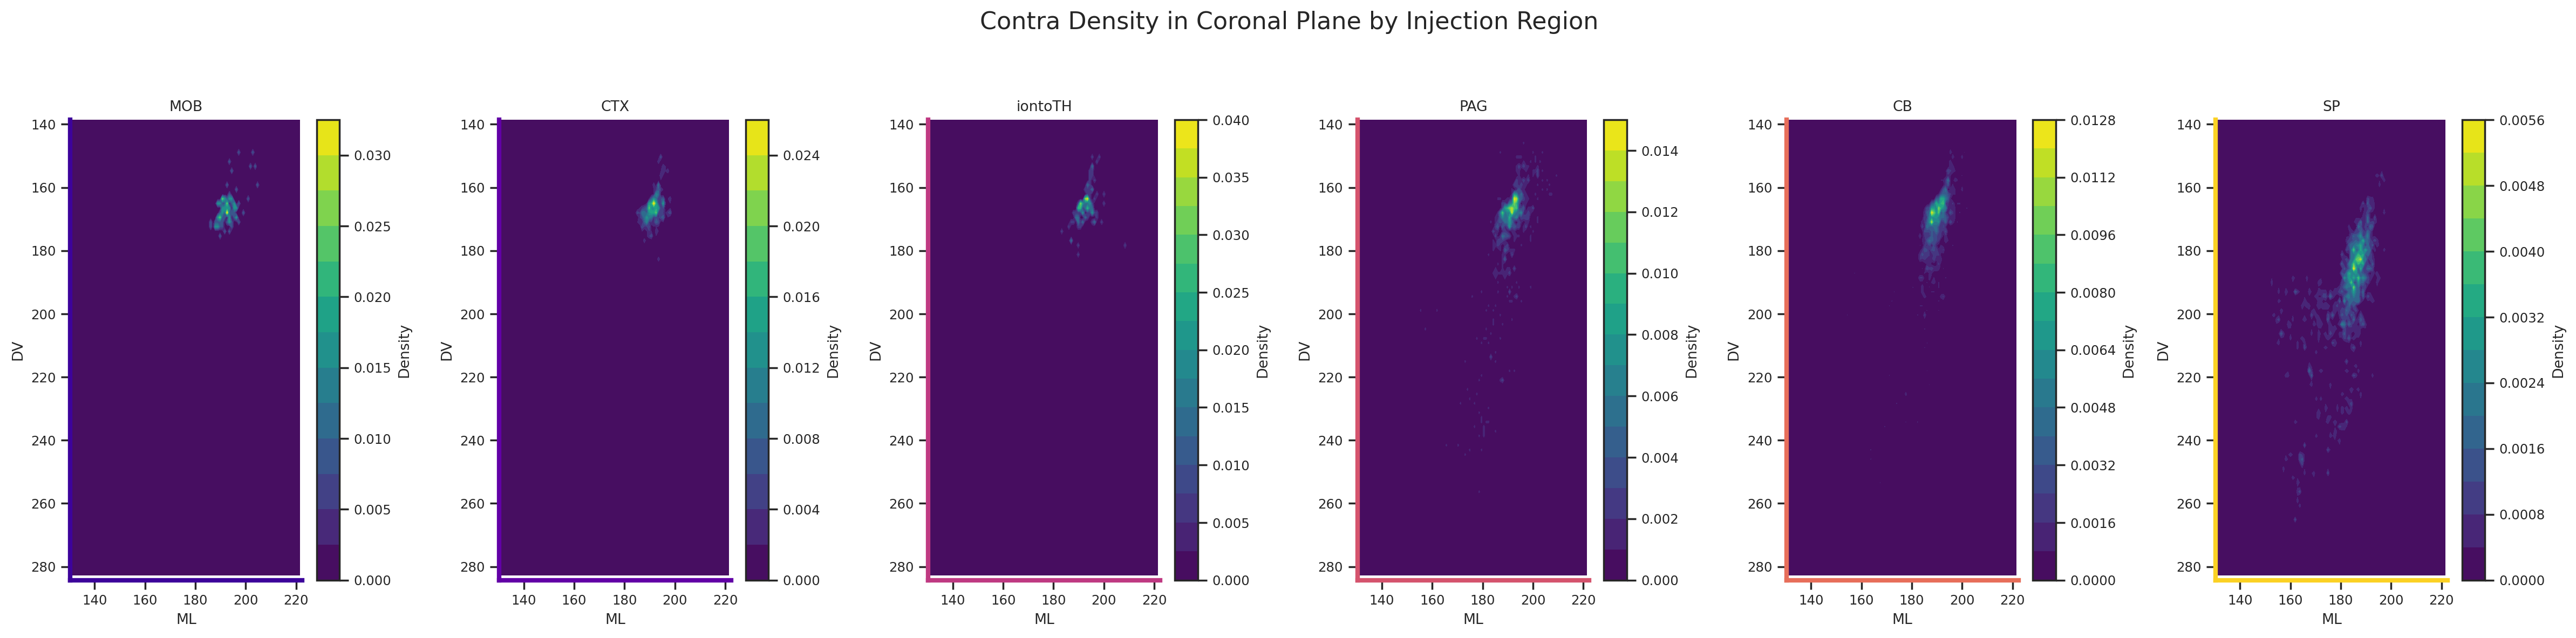

In [13]:
fig_contra, axs_contra = plot_ml_dv_density_by_injection_region(
    df_contra,
    desired_order=["MOB", "CTX", "iontoTH", "PAG", "CB", "SP"],
    region_col_map=region_col_map,
    group_label="contra"
)